In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET_COL = "total_amount"

PROJECT_ROOT_CANDIDATES = [Path.cwd(), *Path.cwd().parents]
DATA_NAMES = [
    "datasets/short_my_clean_3_with_weather.parquet",
    "datasets_local/short_my_clean_3_with_weather.parquet",
]
DATA_CANDIDATES = [base / name for base in PROJECT_ROOT_CANDIDATES for name in DATA_NAMES]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
PROJECT_ROOT = next((base for base in PROJECT_ROOT_CANDIDATES if any((base / name).exists() for name in DATA_NAMES)), Path.cwd())

if DATA_PATH is None:
    def get_display_path(p, root):
        try:
            return str(p.relative_to(root))
        except ValueError:
            return str(p)
            
    checked_paths = "\n".join(f"- {get_display_path(path, PROJECT_ROOT)}" for path in DATA_CANDIDATES)
    raise FileNotFoundError(f"Датасет не найден. Проверенные пути:\n{checked_paths}")

PLOTS_DIR = PROJECT_ROOT / "ml_price" / "figures"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def plot_path(relative_path):
    return PROJECT_ROOT / "ml_price" / relative_path

DARK_BG = "#000000"
PAPER_BG = "#020202"
WHITE = "#F4F7FB"
MUTED = "#B7C0CC"
RED = "#A90000"
GREEN = "#9BFF3D"
BLUE = "#2F80ED"
CYAN = "#00D1FF"
PURPLE = "#7A5CFF"
MAGENTA = "#D642FF"
ORANGE = "#FFB000"

plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor": PAPER_BG,
    "axes.facecolor": DARK_BG,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": WHITE,
    "text.color": WHITE,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": "#ffffff",
    "grid.alpha": 0.14,
    "legend.facecolor": PAPER_BG,
    "legend.edgecolor": MUTED,
})


In [2]:
print("Загружаем датасет...")
print("Путь к датасету:", DATA_PATH.relative_to(PROJECT_ROOT))
df = pd.read_parquet(DATA_PATH)

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")

# Оставляем только 2023-2024 годы на случай выбросов по датам.
df = df.loc[
    df["tpep_pickup_datetime"].ge(pd.Timestamp("2023-01-01"))
    & df["tpep_pickup_datetime"].lt(pd.Timestamp("2025-01-01"))
].copy()

print("Размер таблицы:", df.shape)
print("Диапазон дат:", df["tpep_pickup_datetime"].min(), "-", df["tpep_pickup_datetime"].max())
print("Количество поездок по годам:")
print(df["tpep_pickup_datetime"].dt.year.value_counts().sort_index())
df.head()


Загружаем датасет...
Путь к датасету: datasets\short_my_clean_3_with_weather.parquet
Размер таблицы: (100000, 34)
Диапазон дат: 2023-01-01 00:01:58 - 2023-01-31 23:59:47
Количество поездок по годам:
tpep_pickup_datetime
2023    100000
Name: count, dtype: int64


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,DO_Borough,DO_Zone,DO_lon,DO_lat,distance_group,duration_min,temperature,precipitation,snowfall,weather_code
0,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1,1.17,1.0,N,262,74,2,...,Manhattan,East Harlem North,-73.937346,40.801169,short,4.683333,9.6,0.0,0.0,3
1,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1,0.90,1.0,N,229,237,2,...,Manhattan,Upper East Side South,-73.965635,40.768615,very_short,5.383333,4.2,0.0,0.0,3
2,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1,0.95,1.0,N,45,261,1,...,Manhattan,World Trade Center,-74.013023,40.709139,very_short,7.016667,3.1,0.0,0.0,3
3,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5,0.88,1.0,N,237,141,1,...,Manhattan,Lenox Hill West,-73.959635,40.766948,very_short,19.250000,2.9,0.6,0.0,53
4,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2,1.03,1.0,N,229,140,1,...,Manhattan,Lenox Hill East,-73.954739,40.765484,short,3.666667,5.0,0.0,0.0,1


## 1.1 Разведочный анализ исходных данных

Эти графики помогают до обучения модели проверить распределение стоимости поездок, связь цены с расстоянием и временные закономерности.

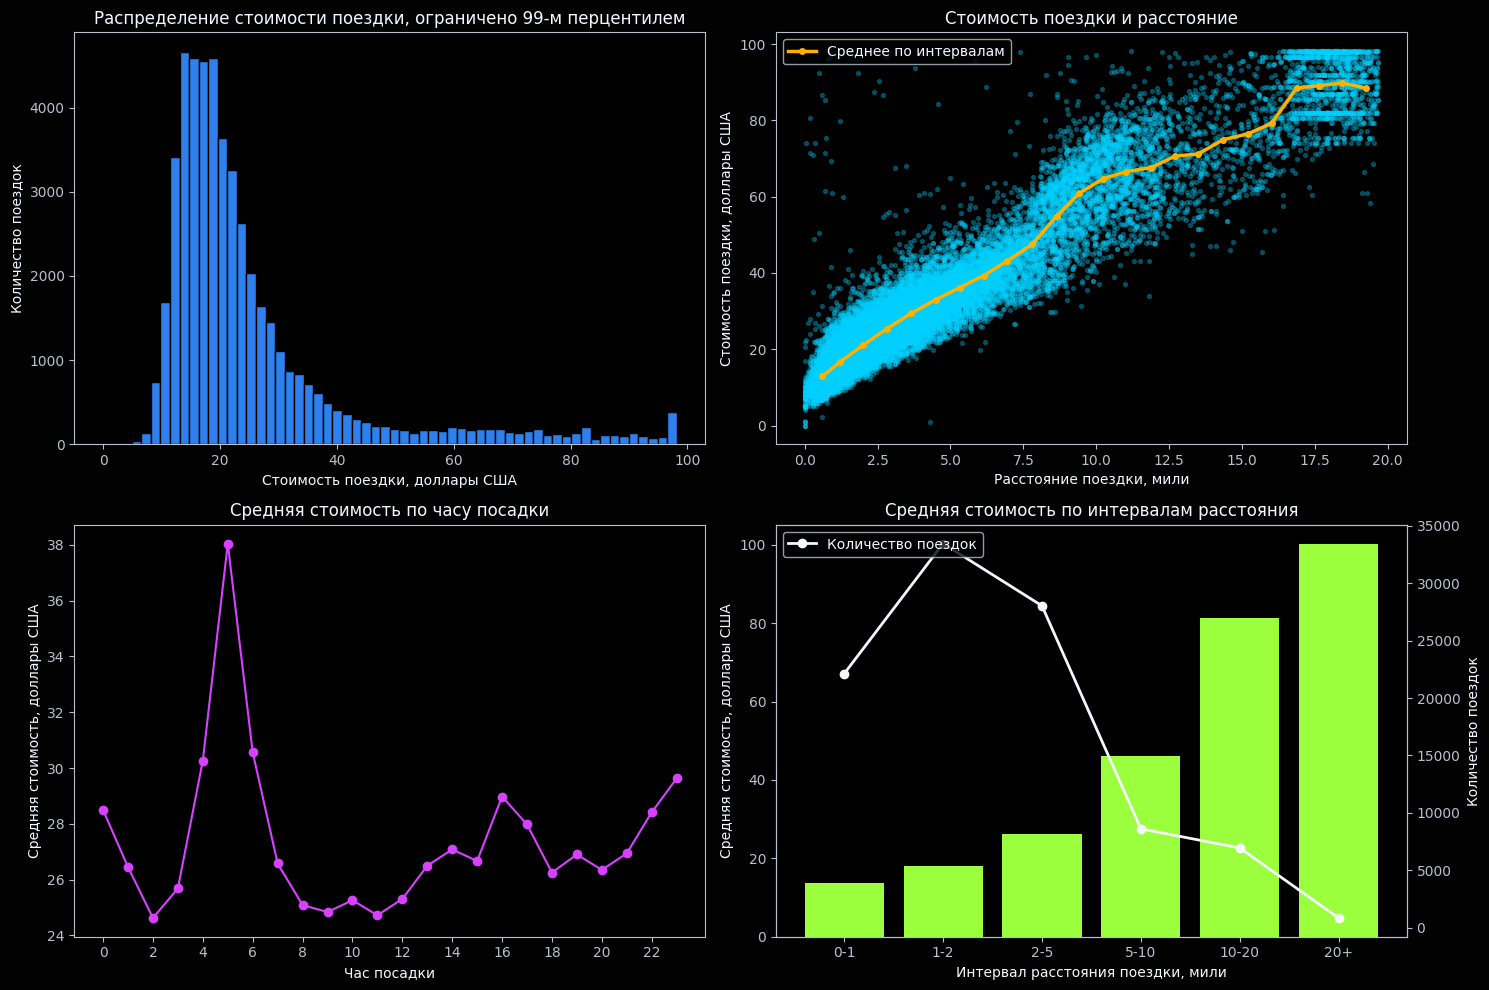

In [3]:
plot_df = df.copy()
plot_df["pickup_date"] = plot_df["tpep_pickup_datetime"].dt.date
plot_df["pickup_hour"] = plot_df["tpep_pickup_datetime"].dt.hour
plot_df["pickup_month"] = plot_df["tpep_pickup_datetime"].dt.to_period("M").astype(str)

price_cap = plot_df[TARGET_COL].quantile(0.99)
distance_cap = plot_df["trip_distance"].quantile(0.99)
plot_sample = plot_df.loc[
    plot_df[TARGET_COL].between(0, price_cap)
    & plot_df["trip_distance"].between(0, distance_cap)
].copy()
plot_sample = plot_sample.sample(min(50_000, len(plot_sample)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(plot_sample[TARGET_COL], bins=60, color=BLUE, edgecolor=DARK_BG)
axes[0, 0].set_title("Распределение стоимости поездки, ограничено 99-м перцентилем")
axes[0, 0].set_xlabel("Стоимость поездки, доллары США")
axes[0, 0].set_ylabel("Количество поездок")

axes[0, 1].scatter(
    plot_sample["trip_distance"],
    plot_sample[TARGET_COL],
    s=8,
    alpha=0.3,
    color=CYAN,
)
trend_bins = np.linspace(0, distance_cap, 25)
trend_df = plot_sample.assign(
    distance_bin=pd.cut(plot_sample["trip_distance"], bins=trend_bins, include_lowest=True)
).groupby("distance_bin", observed=False).agg(
    distance_mid=("trip_distance", "mean"),
    avg_price=(TARGET_COL, "mean"),
).dropna()
axes[0, 1].plot(
    trend_df["distance_mid"],
    trend_df["avg_price"],
    color=ORANGE,
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Среднее по интервалам",
)
axes[0, 1].legend(loc="upper left")
axes[0, 1].set_title("Стоимость поездки и расстояние")
axes[0, 1].set_xlabel("Расстояние поездки, мили")
axes[0, 1].set_ylabel("Стоимость поездки, доллары США")

hourly_price = plot_df.groupby("pickup_hour", observed=False)[TARGET_COL].mean()
axes[1, 0].plot(hourly_price.index, hourly_price.values, marker="o", color=MAGENTA)
axes[1, 0].set_title("Средняя стоимость по часу посадки")
axes[1, 0].set_xlabel("Час посадки")
axes[1, 0].set_ylabel("Средняя стоимость, доллары США")
axes[1, 0].set_xticks(range(0, 24, 2))

distance_bins = [0, 1, 2, 5, 10, 20, np.inf]
distance_labels = ["0-1", "1-2", "2-5", "5-10", "10-20", "20+"]
distance_stats = plot_df.assign(
    distance_bin=pd.cut(
        plot_df["trip_distance"],
        bins=distance_bins,
        labels=distance_labels,
        include_lowest=True,
    )
).groupby("distance_bin", observed=False).agg(
    avg_price=(TARGET_COL, "mean"),
    trips=(TARGET_COL, "size"),
).reset_index()

axes[1, 1].bar(distance_stats["distance_bin"].astype(str), distance_stats["avg_price"], color=GREEN)
axes[1, 1].set_title("Средняя стоимость по интервалам расстояния")
axes[1, 1].set_xlabel("Интервал расстояния поездки, мили")
axes[1, 1].set_ylabel("Средняя стоимость, доллары США")

count_axis = axes[1, 1].twinx()
count_axis.plot(
    distance_stats["distance_bin"].astype(str),
    distance_stats["trips"],
    color=WHITE,
    marker="o",
    linewidth=2,
    label="Количество поездок",
)
count_axis.set_ylabel("Количество поездок")
count_axis.legend(loc="upper left")

fig.tight_layout()
fig.savefig(plot_path("figures/01_data_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

In [4]:
print("1. Создаем временные, бизнес-, географические и погодные признаки...")

model_df = df.copy()

# Fill low-cardinality categorical columns before splitting/features.
model_df["store_and_fwd_flag"] = model_df["store_and_fwd_flag"].fillna("unknown").astype(str)
model_df["distance_group"] = model_df["distance_group"].astype(str).replace("nan", "unknown")
model_df["PU_Borough"] = model_df["PU_Borough"].fillna("unknown").astype(str)
model_df["DO_Borough"] = model_df["DO_Borough"].fillna("unknown").astype(str)

model_df["pickup_hour"] = model_df["tpep_pickup_datetime"].dt.hour
model_df["pickup_dayofweek"] = model_df["tpep_pickup_datetime"].dt.dayofweek
model_df["pickup_month"] = model_df["tpep_pickup_datetime"].dt.month
model_df["pickup_day"] = model_df["tpep_pickup_datetime"].dt.day
model_df["pickup_weekofyear"] = model_df["tpep_pickup_datetime"].dt.isocalendar().week.astype(int)
model_df["is_weekend"] = model_df["pickup_dayofweek"].isin([5, 6]).astype(int)
model_df["is_rush_hour"] = (
    (model_df["pickup_dayofweek"] < 5)
    & (model_df["pickup_hour"] >= 16)
    & (model_df["pickup_hour"] < 20)
).astype(int)
model_df["is_night_tariff"] = ((model_df["pickup_hour"] >= 20) | (model_df["pickup_hour"] < 6)).astype(int)

model_df["hour_sin"] = np.sin(2 * np.pi * model_df["pickup_hour"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["pickup_hour"] / 24)
model_df["dow_sin"] = np.sin(2 * np.pi * model_df["pickup_dayofweek"] / 7)
model_df["dow_cos"] = np.cos(2 * np.pi * model_df["pickup_dayofweek"] / 7)
model_df["month_sin"] = np.sin(2 * np.pi * model_df["pickup_month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["pickup_month"] / 12)

model_df["lat_diff"] = (model_df["DO_lat"] - model_df["PU_lat"]).abs()
model_df["lon_diff"] = (model_df["DO_lon"] - model_df["PU_lon"]).abs()
model_df["gps_distance"] = model_df["lat_diff"] + model_df["lon_diff"]
model_df["distance_ratio"] = model_df["trip_distance"] / (model_df["gps_distance"] + 0.001)
model_df["distance_ratio"] = model_df["distance_ratio"].clip(0, 15)

model_df["duration_min"] = model_df["duration_min"].clip(lower=0.1)
model_df["speed_mph"] = model_df["trip_distance"] / (model_df["duration_min"] / 60 + 0.01)
model_df["speed_mph"] = model_df["speed_mph"].clip(0, 80)
model_df["log_trip_distance"] = np.log1p(model_df["trip_distance"])
model_df["log_duration_min"] = np.log1p(model_df["duration_min"])

model_df["has_precipitation"] = (model_df["precipitation"] > 0).astype(int)
model_df["has_snowfall"] = (model_df["snowfall"] > 0).astype(int)
model_df["bad_weather"] = ((model_df["precipitation"] > 0) | (model_df["snowfall"] > 0)).astype(int)
model_df["precipitation_x_rush_hour"] = model_df["precipitation"] * model_df["is_rush_hour"]
model_df["snowfall_x_rush_hour"] = model_df["snowfall"] * model_df["is_rush_hour"]

airport_zone_ids = {1, 132, 138}
model_df["pickup_airport"] = model_df["PULocationID"].isin(airport_zone_ids).astype(int)
model_df["dropoff_airport"] = model_df["DOLocationID"].isin(airport_zone_ids).astype(int)
model_df["airport_trip"] = ((model_df["pickup_airport"] == 1) | (model_df["dropoff_airport"] == 1)).astype(int)
model_df["same_zone"] = (model_df["PULocationID"] == model_df["DOLocationID"]).astype(int)
model_df["same_borough"] = (model_df["PU_Borough"] == model_df["DO_Borough"]).astype(int)
model_df["interborough_trip"] = (model_df["PU_Borough"] != model_df["DO_Borough"]).astype(int)

model_df["route_id"] = model_df["PULocationID"].astype(str) + "_" + model_df["DOLocationID"].astype(str)

print("Признаки созданы")


1. Создаем временные, бизнес-, географические и погодные признаки...
Признаки созданы


In [5]:
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "payment_type",
    "store_and_fwd_flag",
    "PU_Borough",
    "DO_Borough",
    "distance_group",
]

target_encoding_cols = [
    "PULocationID",
    "DOLocationID",
    "route_id",
    "RatecodeID",
]

target_encoded_feature_names = [
    "PU_zone_average_price",
    "DO_zone_average_price",
    "route_average_price",
    "ratecode_average_price",
]

weather_cols = [
    "temperature",
    "precipitation",
    "snowfall",
    "weather_code",
    "has_precipitation",
    "has_snowfall",
    "bad_weather",
    "precipitation_x_rush_hour",
    "snowfall_x_rush_hour",
]

time_cols = [
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "pickup_day",
    "pickup_weekofyear",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

trip_cols = [
    "trip_distance",
    "passenger_count",
    "is_weekend",
    "is_rush_hour",
    "is_night_tariff",
    "gps_distance",
    "distance_ratio",
    "duration_min",
    "speed_mph",
    "log_trip_distance",
    "log_duration_min",
    "pickup_airport",
    "dropoff_airport",
    "airport_trip",
    "same_zone",
    "same_borough",
    "interborough_trip",
]

numerical_cols = [
    *trip_cols,
    *time_cols,
    *weather_cols,
    *target_encoded_feature_names,
]

base_feature_cols = [
    "PULocationID",
    "DOLocationID",
    "route_id",
    "tpep_pickup_datetime",
    *categorical_cols,
    *[col for col in numerical_cols if col not in target_encoded_feature_names],
]

model_df = model_df.dropna(subset=[TARGET_COL, *base_feature_cols]).copy()
model_df = model_df.sort_values("tpep_pickup_datetime").reset_index(drop=True)

# Временное разбиение: обучаемся на ранних данных, тестируемся на последних месяцах.
test_start = pd.Timestamp("2024-10-01")
train_mask = model_df["tpep_pickup_datetime"] < test_start
test_mask = model_df["tpep_pickup_datetime"] >= test_start

if test_mask.sum() == 0 or train_mask.sum() == 0:
    split_idx = int(len(model_df) * 0.8)
    train_mask = model_df.index < split_idx
    test_mask = model_df.index >= split_idx
    print("Резервное разбиение: первые 80% данных - обучение, последние 20% - тест")
else:
    print("Временное разбиение: обучение до", test_start.date(), "тест с", test_start.date())

X_train_base = model_df.loc[train_mask, base_feature_cols].copy()
X_test_base = model_df.loc[test_mask, base_feature_cols].copy()
y_train = model_df.loc[train_mask, TARGET_COL].copy()
y_test = model_df.loc[test_mask, TARGET_COL].copy()

X_train_base = X_train_base.drop(columns=["tpep_pickup_datetime"])
X_test_base = X_test_base.drop(columns=["tpep_pickup_datetime"])

print("Размер обучающей выборки:", X_train_base.shape)
print("Размер тестовой выборки:", X_test_base.shape)
print("Среднее значение целевой переменной на обучении:", round(y_train.mean(), 2))
print("Среднее значение целевой переменной на тесте:", round(y_test.mean(), 2))


Резервное разбиение: первые 80% данных - обучение, последние 20% - тест
Размер обучающей выборки: (80000, 47)
Размер тестовой выборки: (20000, 47)
Среднее значение целевой переменной на обучении: 26.97
Среднее значение целевой переменной на тесте: 26.51


## 2.1 Проверка разбиения обучение/тест

Эти графики показывают, похожи ли распределения целевой переменной в train и test, а также есть ли заметный сдвиг стоимости в тестовом периоде.

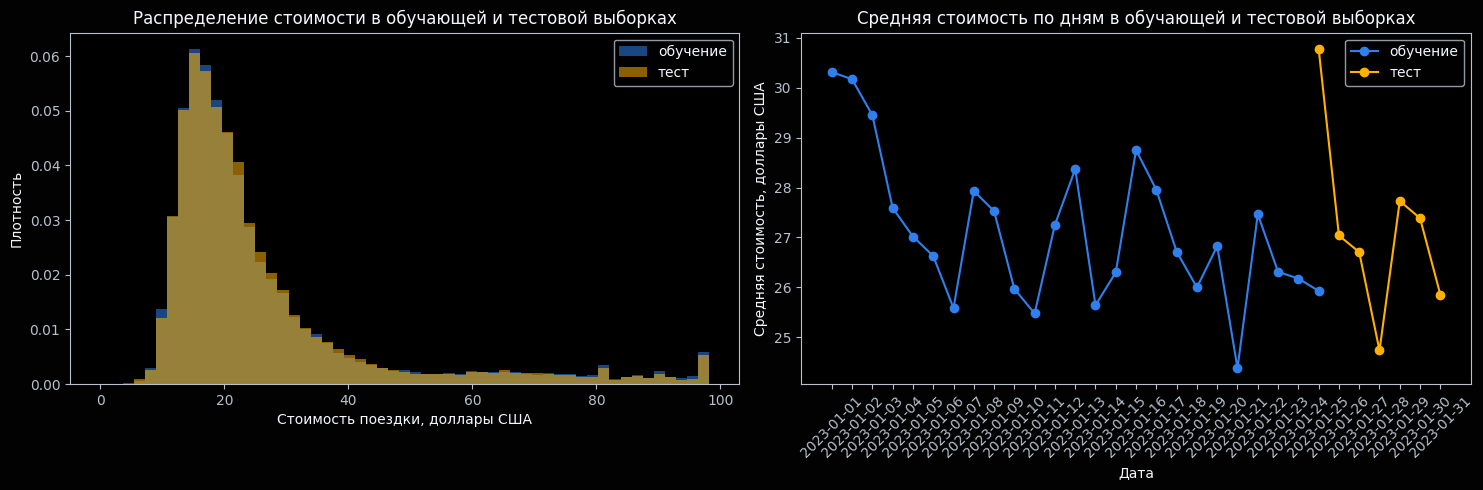

In [6]:
split_plot_df = pd.concat(
    [
        pd.DataFrame({"split": "обучение", TARGET_COL: y_train}),
        pd.DataFrame({"split": "тест", TARGET_COL: y_test}),
    ],
    ignore_index=True,
)
price_cap_split = split_plot_df[TARGET_COL].quantile(0.99)
split_plot_df = split_plot_df[split_plot_df[TARGET_COL].between(0, price_cap_split)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for split_name, color in [("обучение", BLUE), ("тест", ORANGE)]:
    values = split_plot_df.loc[split_plot_df["split"] == split_name, TARGET_COL]
    axes[0].hist(values, bins=55, alpha=0.55, label=split_name, color=color, density=True)
axes[0].set_title("Распределение стоимости в обучающей и тестовой выборках")
axes[0].set_xlabel("Стоимость поездки, доллары США")
axes[0].set_ylabel("Плотность")
axes[0].legend()

split_time_df = model_df.assign(
    pickup_date=model_df["tpep_pickup_datetime"].dt.date,
    pickup_month=model_df["tpep_pickup_datetime"].dt.to_period("M").astype(str),
    split=np.where(train_mask, "обучение", "тест"),
)

if split_time_df["pickup_month"].nunique() <= 1:
    time_col = "pickup_date"
    time_label = "Дата"
    title = "Средняя стоимость по дням в обучающей и тестовой выборках"
else:
    time_col = "pickup_month"
    time_label = "Месяц"
    title = "Средняя стоимость по месяцам в обучающей и тестовой выборках"

time_target = (
    split_time_df.groupby([time_col, "split"], observed=False)[TARGET_COL]
    .mean()
    .reset_index()
)

for split_name, color in [("обучение", BLUE), ("тест", ORANGE)]:
    part = time_target[time_target["split"] == split_name]
    axes[1].plot(part[time_col].astype(str), part[TARGET_COL], marker="o", label=split_name, color=color)
axes[1].set_title(title)
axes[1].set_xlabel(time_label)
axes[1].set_ylabel("Средняя стоимость, доллары США")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

fig.tight_layout()
fig.savefig(plot_path("figures/02_train_test_split.png"), dpi=150, bbox_inches="tight")
plt.show()


In [7]:
def add_target_encoding(train_x, test_x, train_y, source_cols, encoded_cols, smooth=50):
    train_x = train_x.copy()
    test_x = test_x.copy()
    global_mean = float(train_y.mean())

    train_with_target = train_x.copy()
    train_with_target[TARGET_COL] = train_y.values

    for source_col, encoded_col in zip(source_cols, encoded_cols):
        stats = train_with_target.groupby(source_col, observed=False)[TARGET_COL].agg(["mean", "count"])
        smoothed = (stats["mean"] * stats["count"] + global_mean * smooth) / (stats["count"] + smooth)
        train_x[encoded_col] = train_x[source_col].map(smoothed).fillna(global_mean).astype(float)
        test_x[encoded_col] = test_x[source_col].map(smoothed).fillna(global_mean).astype(float)

    return train_x, test_x

print("2. Добавляем сглаженное target encoding только по обучающей выборке...")
X_train_full, X_test_full = add_target_encoding(
    X_train_base,
    X_test_base,
    y_train,
    target_encoding_cols,
    target_encoded_feature_names,
)

X_train = X_train_full[numerical_cols + categorical_cols].copy()
X_test = X_test_full[numerical_cols + categorical_cols].copy()

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

print("Итоговое количество признаков:", X_train.shape[1])
print("Итоговый размер обучающей выборки:", X_train.shape)
print("Итоговый размер тестовой выборки:", X_test.shape)


2. Добавляем сглаженное target encoding только по обучающей выборке...
Итоговое количество признаков: 48
Итоговый размер обучающей выборки: (80000, 48)
Итоговый размер тестовой выборки: (20000, 48)


In [8]:
print("3. Обучаем HistGradientBoostingRegressor...")

boosting_model = HistGradientBoostingRegressor(
    categorical_features="from_dtype",
    max_iter=900,
    max_leaf_nodes=127,
    learning_rate=0.015,
    min_samples_leaf=40,
    l2_regularization=0.01,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    random_state=42,
)

boosting_model.fit(X_train, y_train)
print("Модель бустинга обучена")
print("Использовано итераций:", boosting_model.n_iter_)


3. Обучаем HistGradientBoostingRegressor...
Модель бустинга обучена
Использовано итераций: 900


In [9]:
print("4. Оцениваем модель бустинга...")

y_pred = boosting_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("================ МЕТРИКИ БУСТИНГА ================")
print(f"MAE:  {mae:.2f} $")
print(f"RMSE: {rmse:.2f} $")
print(f"R2:   {r2 * 100:.1f}%")
print("==================================================")


4. Оцениваем модель бустинга...
================ МЕТРИКИ БУСТИНГА ================
MAE:  1.60 $
RMSE: 4.13 $
R2:   95.4%


## 4.1 Диагностика качества на тесте

Эти четыре графика показывают, как обученный `HistGradientBoostingRegressor` ведет себя на тестовой выборке.

- `Фактическая и прогнозная стоимость`: точки должны быть близко к диагональной линии. Чем дальше точка от линии, тем больше ошибка прогноза.
- `Распределение остатков`: остатки считаются как `факт - прогноз`. Если распределение сосредоточено около нуля, у модели нет сильного общего завышения или занижения прогноза.
- `Остатки и прогноз`: остатки не должны образовывать явный паттерн. Кривая или расширяющееся облако точек означает, что модель хуже работает на некоторых диапазонах цен.
- `Средняя абсолютная ошибка по часу посадки`: показывает, в какие часы бустинг ошибается сильнее в среднем.

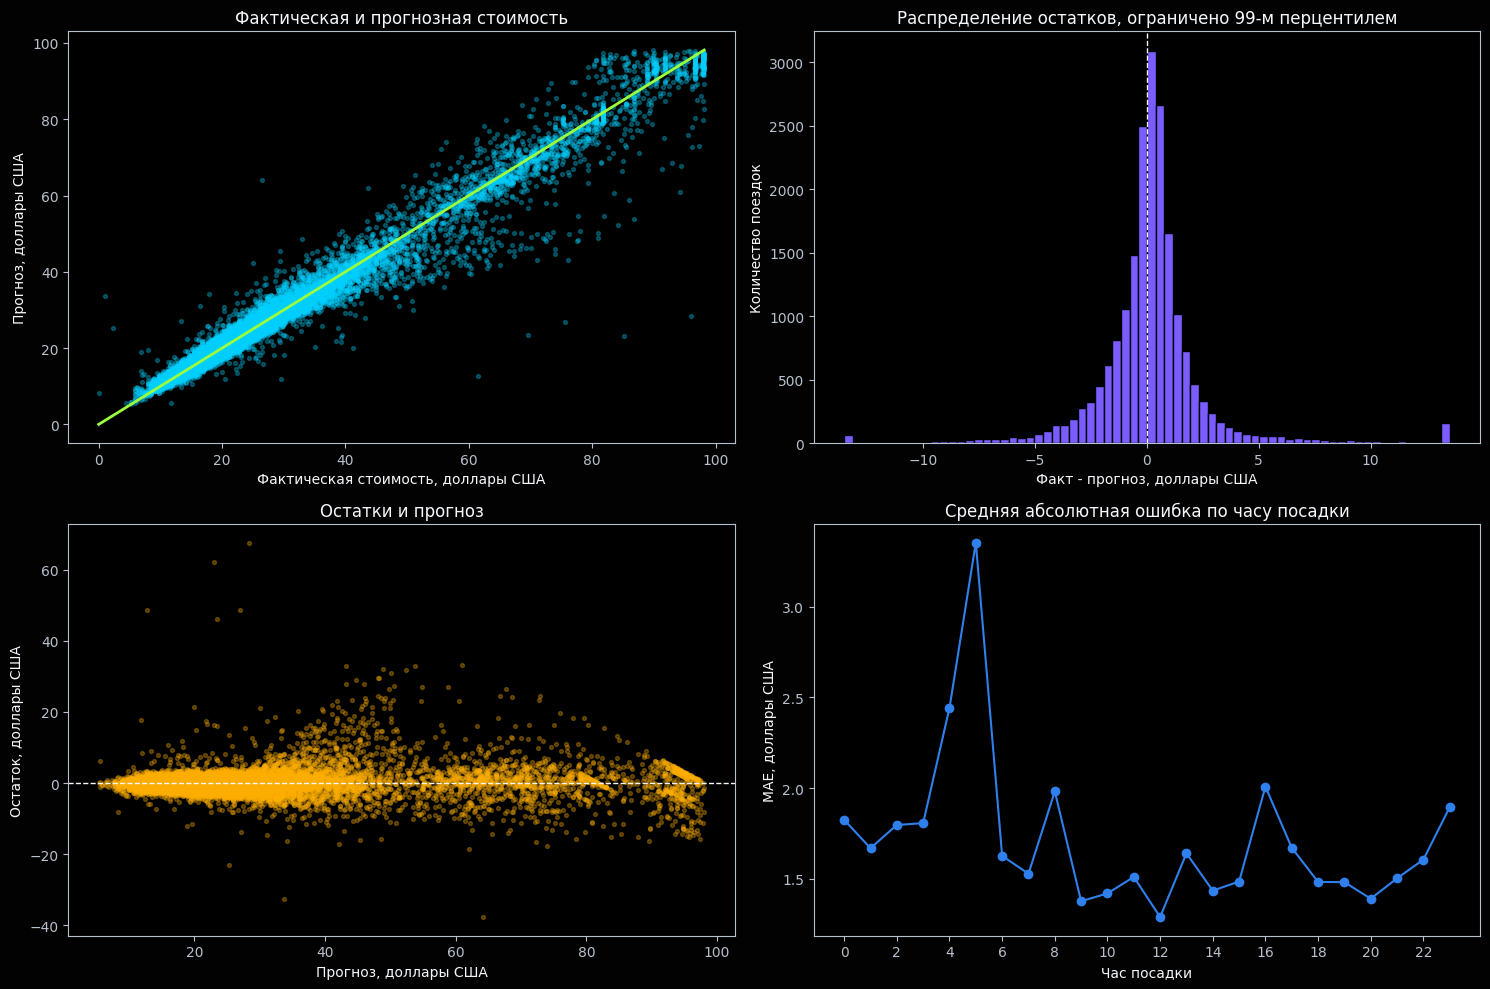

In [10]:
diagnostics_df = X_test_base.copy()
diagnostics_df["pickup_datetime"] = model_df.loc[test_mask, "tpep_pickup_datetime"].values
diagnostics_df["y_true"] = y_test.values
diagnostics_df["y_pred"] = y_pred
diagnostics_df["residual"] = diagnostics_df["y_true"] - diagnostics_df["y_pred"]
diagnostics_df["abs_error"] = diagnostics_df["residual"].abs()
diagnostics_df["pickup_hour"] = diagnostics_df["pickup_datetime"].dt.hour
diagnostics_df["pickup_month"] = diagnostics_df["pickup_datetime"].dt.to_period("M").astype(str)

price_cap_diag = diagnostics_df[["y_true", "y_pred"]].quantile(0.99).max()
plot_diag = diagnostics_df[
    diagnostics_df["y_true"].between(0, price_cap_diag)
    & diagnostics_df["y_pred"].between(0, price_cap_diag)
].copy()
plot_diag = plot_diag.sample(min(50_000, len(plot_diag)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].scatter(plot_diag["y_true"], plot_diag["y_pred"], s=8, alpha=0.3, color=CYAN)
axes[0, 0].plot([0, price_cap_diag], [0, price_cap_diag], color=GREEN, linewidth=2)
axes[0, 0].set_title("Фактическая и прогнозная стоимость")
axes[0, 0].set_xlabel("Фактическая стоимость, доллары США")
axes[0, 0].set_ylabel("Прогноз, доллары США")

residual_cap = diagnostics_df["residual"].abs().quantile(0.99)
axes[0, 1].hist(
    diagnostics_df["residual"].clip(-residual_cap, residual_cap),
    bins=70,
    color=PURPLE,
    edgecolor=DARK_BG,
)
axes[0, 1].axvline(0, color=WHITE, linewidth=1, linestyle="--")
axes[0, 1].set_title("Распределение остатков, ограничено 99-м перцентилем")
axes[0, 1].set_xlabel("Факт - прогноз, доллары США")
axes[0, 1].set_ylabel("Количество поездок")

axes[1, 0].scatter(plot_diag["y_pred"], plot_diag["residual"], s=8, alpha=0.3, color=ORANGE)
axes[1, 0].axhline(0, color=WHITE, linewidth=1, linestyle="--")
axes[1, 0].set_title("Остатки и прогноз")
axes[1, 0].set_xlabel("Прогноз, доллары США")
axes[1, 0].set_ylabel("Остаток, доллары США")

hourly_error = diagnostics_df.groupby("pickup_hour", observed=False)["abs_error"].mean()
axes[1, 1].plot(hourly_error.index, hourly_error.values, marker="o", color=BLUE)
axes[1, 1].set_title("Средняя абсолютная ошибка по часу посадки")
axes[1, 1].set_xlabel("Час посадки")
axes[1, 1].set_ylabel("MAE, доллары США")
axes[1, 1].set_xticks(range(0, 24, 2))

fig.tight_layout()
fig.savefig(plot_path("figures/03_model_diagnostics.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4.2 Анализ ошибок по сегментам

Эти графики сравнивают ошибку бустинга по разным бизнес-сегментам.

Каждый столбец показывает MAE для сегмента на тестовой выборке. Чем выше столбец, тем хуже модель предсказывает этот сегмент. Это помогает найти слабые места модели: например, отдельные районы посадки/высадки, тарифные коды или поездки в плохую погоду. Сегменты, где меньше 50 поездок, исключены, чтобы не делать выводы по слишком шумным данным.

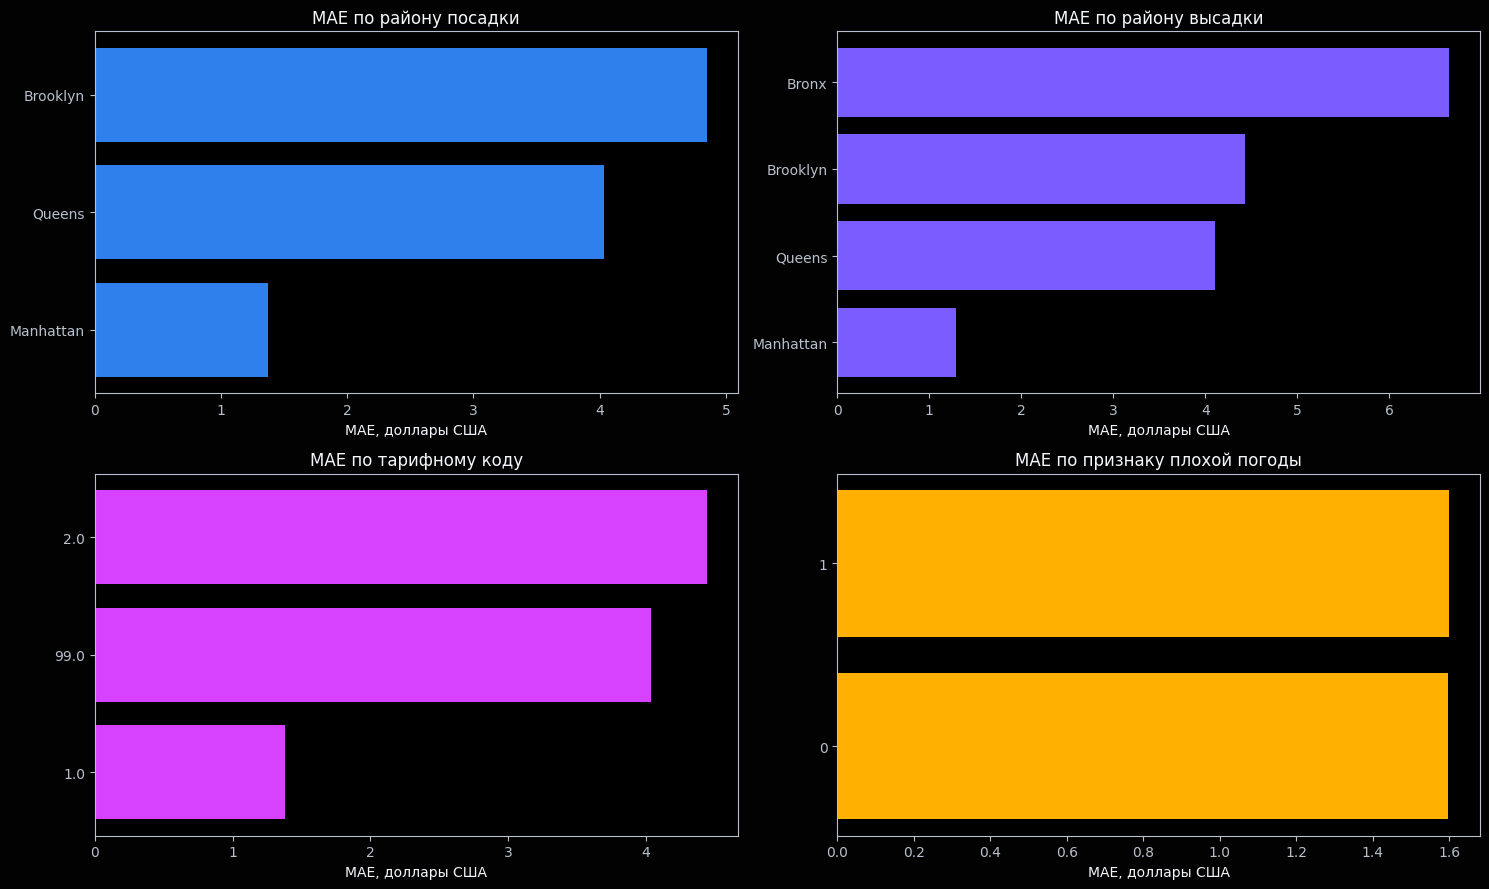

In [11]:
segment_specs = [
    ("PU_Borough", "MAE по району посадки"),
    ("DO_Borough", "MAE по району высадки"),
    ("RatecodeID", "MAE по тарифному коду"),
    ("bad_weather", "MAE по признаку плохой погоды"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

colors_for_segments = [BLUE, PURPLE, MAGENTA, ORANGE]

for (ax, (col, title)), color in zip(zip(axes, segment_specs), colors_for_segments):
    seg = (
        diagnostics_df.groupby(col, observed=False)
        .agg(mae=("abs_error", "mean"), trips=("abs_error", "size"))
        .query("trips >= 50")
        .sort_values("mae", ascending=False)
        .head(12)
        .sort_values("mae")
    )
    ax.barh(seg.index.astype(str), seg["mae"], color=color)
    ax.set_title(title)
    ax.set_xlabel("MAE, доллары США")
    ax.set_ylabel("")

fig.tight_layout()
fig.savefig(plot_path("figures/04_segment_errors.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4.3 Важность признаков через permutation importance

Этот график оценивает, на какие признаки обученный бустинг опирается сильнее всего.

Для каждого признака значения случайно перемешиваются в тестовой подвыборке, после чего заново считается MAE. Если после перемешивания признака MAE сильно растет, значит модель действительно использовала этот признак. Это интерпретация конкретной обученной модели, а не просто описание исходного датасета.

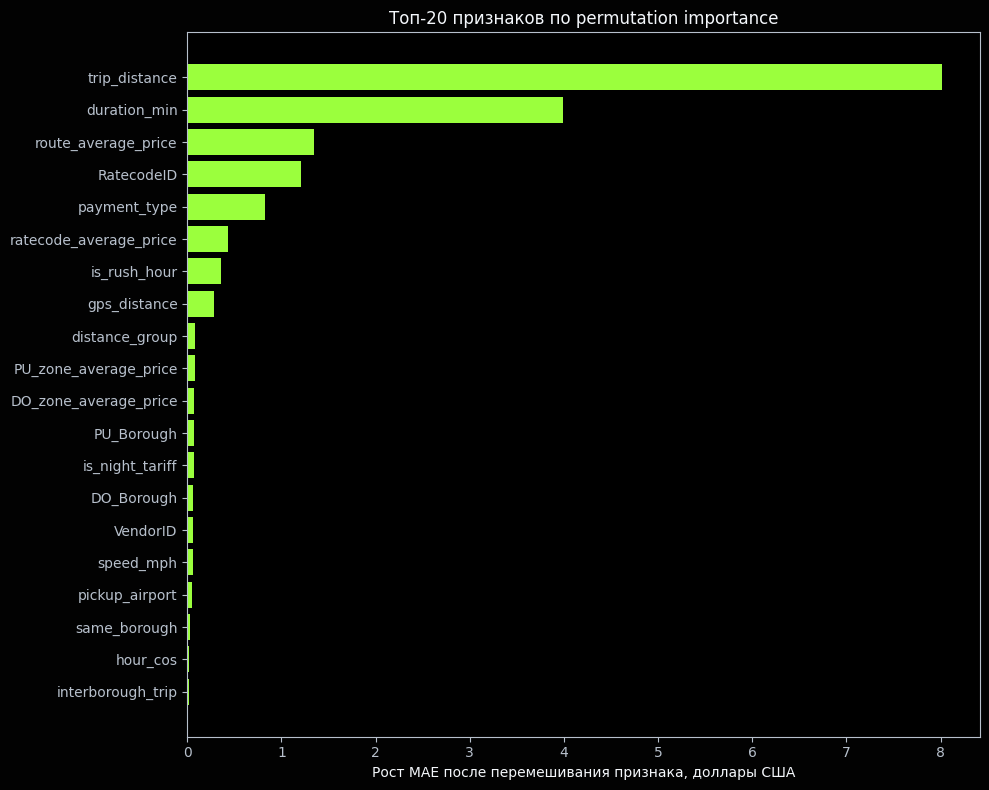

,Признак,Рост MAE,Стандартное отклонение
0,trip_distance,8.018493,0.081791
7,duration_min,3.991749,0.038992
39,route_average_price,1.345782,0.038651
42,RatecodeID,1.208803,0.009942
43,payment_type,0.821466,0.011406
40,ratecode_average_price,0.435787,0.001403
3,is_rush_hour,0.355127,0.001122
5,gps_distance,0.281888,0.017700
47,distance_group,0.086027,0.004508
37,PU_zone_average_price,0.084797,0.002783


In [12]:
importance_sample_size = min(5_000, len(X_test))
importance_idx = X_test.sample(importance_sample_size, random_state=42).index

perm = permutation_importance(
    boosting_model,
    X_test.loc[importance_idx],
    y_test.loc[importance_idx],
    n_repeats=3,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mae_increase": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mae_increase", ascending=False)

top_importance = importance_df.head(20).sort_values("importance_mae_increase")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_importance["feature"], top_importance["importance_mae_increase"], color=GREEN)
ax.set_title("Топ-20 признаков по permutation importance")
ax.set_xlabel("Рост MAE после перемешивания признака, доллары США")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(plot_path("figures/05_permutation_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

importance_df.head(20).rename(columns={
    "feature": "Признак",
    "importance_mae_increase": "Рост MAE",
    "importance_std": "Стандартное отклонение",
})

In [13]:
prediction_preview = pd.DataFrame({
    "Фактическая стоимость": y_test.reset_index(drop=True).head(20),
    "Прогнозная стоимость": pd.Series(y_pred).head(20),
})

prediction_preview["Абсолютная ошибка"] = (
    prediction_preview["Фактическая стоимость"] - prediction_preview["Прогнозная стоимость"]
).abs()
prediction_preview


,Фактическая стоимость,Прогнозная стоимость,Абсолютная ошибка
0,68.45,47.125916,21.324084
1,19.20,22.788848,3.588848
2,48.75,47.845095,0.904905
3,19.90,20.803884,0.903884
4,28.73,29.823621,1.093621
5,17.16,17.922765,0.762765
6,16.32,16.582025,0.262025
7,12.95,13.339764,0.389764
8,24.05,24.049298,0.000702
9,81.80,90.256606,8.456606
